# Laboratori 4 — Hyrje ne Teorine e Grafeve

Ne kete laborator do te njihemi me **grafet** si strukture matematikore dhe do te mesojme:
- Elementet baze dhe terminologjine e sakte akademike
- Llojet kryesore te grafeve
- Menyrat e paraqitjes se grafeve: liste fqinjesie dhe matrice fqinjesie
- Parametrat e rendesishem: rendi dhe permasa

---

## Teoria — Bazat e Teorise se Grafeve

Nje **graf** eshte nje çift i renditur **G = (V, E)** ku:
- **V** — bashkesia e **kulmeve**: elementet e grafit
- **E** — bashkesia e **brinjeve**: lidhjet midis kulmeve

Çdo brinje **e ∈ E** eshte nje çift kulmesh **(u, v)** ku **u, v ∈ V**.

### Terminologjia baze

| Term shqip | Term anglisht | Definicion |
|---|---|---|
| **Kulm** | Vertex / Node | Elementi baze i grafit |
| **Brinje** | Edge / Arc | Lidhja midis dy kulmeve |
| **Fuqia** | Degree | Numri i brinjeve qe lidhen me nje kulm |
| **Lak** | Loop | Brinje qe lidh kulmin me vetveten: (v, v) |
| **Brinje paralele** | Parallel edge | Dy ose me shume brinje midis te njejteve kulme |
| **Kulme ngjitur** | Adjacent vertices | Dy kulme te lidhura me nje brinje |
| **Rend** | Order | Numri i kulmeve: \|V\| |
| **Permasa** | Size | Numri i brinjeve: \|E\| |

### Llojet kryesore te grafeve

| Lloji | Karakteristika |
|---|---|
| **Graf i thjeshte** | Pa lake, pa brinje paralele |
| **Multigraf** | Lejon brinje paralele midis te njejteve kulme |
| **Graf me lake** | Lejon lake (u,u) |
| **Graf i drejtuar** | Brinjet kane drejtim: (u→v) ≠ (v→u) |
| **Graf i padrejtuar** | Brinjet jane simetrike: (u,v) = (v,u) |
| **Graf i plote** | Çdo çift kulmesh eshte i lidhur |
| **Graf bosh** | Pa brinje fare |

---

## Ushtrimi 1 — Vizualizim Interaktiv: Ndërtoni Grafin Tuaj

### Qëllimi
Të kuptojmë vizualisht elementet e grafit duke i **ndërtuar vetë** në mënyrë interaktive —
kulme, brinje, lake dhe brinje paralele.

### Kontrollat
| Veprim | Efekti |
|---|---|
| **Klik i majtë** në hapësirë boshe | Shton kulm të ri |
| **Klik i majtë** mbi kulm → klik mbi tjetër | Shton brinjë (u, v) |
| **Klik i majtë** mbi të njëjtin kulm dy herë | Shton lak (v, v) |
| **Klik i djathtë** mbi kulm | Heq kulmin dhe brinjet e tij |
| **I** | Shfaq info: rendi, përmasa, fuqite |
| **R** | Rivendos grafin bosh |
| **Q** | Mbyll |

### Çfarë të vëzhgoni
- Çfarë ndodh me **fuqine** e kulmit kur shtoni një lak?
- A mund të ndërtoni një **multigraf**? *(dy brinje midis të njëjtëve kulme)*
- Ndërtoni grafin e plotë **K₄** *(4 kulme, çdo çift i lidhur)*. Sa brinje ka?

In [3]:
import pygame, math, os
from collections import defaultdict

pygame.init()
screen = pygame.display.set_mode((1100, 720), pygame.RESIZABLE)
pygame.display.set_caption("Laborator 4 — Ushtrimi 1: Ndertoni Grafin Tuaj")
fB = pygame.font.Font(None, 36)
fM = pygame.font.Font(None, 26)
fS = pygame.font.Font(None, 21)

BG       = (14, 14, 26);   PB       = (22, 22, 40)
NODE     = (80, 160, 255); NODE_SEL = (255, 180, 50); NODE_HOV = (120, 200, 255)
EDGE_COL = (100, 100, 170); LOOP_COL = (255, 120, 80);  PARA_COL = (80, 220, 140)
TC       = (220, 220, 240); DC       = (110, 110, 140)
OK       = (72, 199, 142);  ERR      = (255, 90, 80)

nodes    = {}        # id -> (x, y, label)
edges    = []        # liste e çifteve (id1, id2) — lejon dublikate dhe lake
node_id  = 0
selected = None
show_info = False

def node_at(x, y):
    for nid, (nx_, ny_, _) in nodes.items():
        if math.hypot(x - nx_, y - ny_) < 24:
            return nid
    return None

def degree(nid):
    # Laku numerohet 2 here
    d = 0
    for a, b in edges:
        if a == b == nid: d += 2
        elif a == nid or b == nid: d += 1
    return d

def has_loop(nid):
    return any(a == b == nid for a, b in edges)

def count_parallel(u, v):
    if u == v: return 0
    a, b = min(u, v), max(u, v)
    return sum(1 for x, y in edges if min(x,y)==a and max(x,y)==b)

def draw():
    global selected
    W, H = screen.get_size()
    mx, my = pygame.mouse.get_pos()
    hovered = node_at(mx, my)
    screen.fill(BG)

    # Titulli
    t = fB.render("Ushtrimi 1 — Ndertoni Grafin Tuaj", True, TC)
    screen.blit(t, (W//2 - t.get_width()//2, 12))
    hint = ("Klik i majte: shto kulm / brinje / lak  |  Klik i djathte: hiq  |"
            "  I: info  |  R: rivendos  |  Q: del")
    screen.blit(fS.render(hint, True, DC), (W//2 - fS.size(hint)[0]//2, 46))

    # Brinja gjysme-aktive
    if selected is not None and selected in nodes:
        sx, sy, _ = nodes[selected]
        pygame.draw.line(screen, (255, 200, 50, 120), (sx, sy), (mx, my), 2)

    # Brinjet
    drawn_pairs = defaultdict(int)
    for a, b in edges:
        if a == b:  # lak
            nx_, ny_, _ = nodes[a]
            pygame.draw.circle(screen, LOOP_COL, (nx_ + 28, ny_ - 28), 18, 2)
            lt = fS.render("lak", True, LOOP_COL)
            screen.blit(lt, (nx_ + 38, ny_ - 50))
        else:
            key = (min(a,b), max(a,b))
            offset = drawn_pairs[key] * 18
            drawn_pairs[key] += 1
            ax_, ay_, _ = nodes[a]; bx_, by_, _ = nodes[b]
            # Zhvendos brinjet paralele
            if offset > 0:
                dx = by_ - ay_; dy = ax_ - bx_
                length = math.hypot(dx, dy) or 1
                dx /= length; dy /= length
                ax_ += dx*offset; ay_ += dy*offset
                bx_ += dx*offset; by_ += dy*offset
                col = PARA_COL
                # Paraqitja paralele
                mx2, my2 = (ax_+bx_)//2, (ay_+by_)//2
                pt = fS.render("paralele", True, PARA_COL)
                screen.blit(pt, (int(mx2)+4, int(my2)))
            else:
                col = EDGE_COL
            pygame.draw.line(screen, col, (int(ax_), int(ay_)), (int(bx_), int(by_)), 2)

    # Kulmet
    for nid, (nx_, ny_, lbl) in nodes.items():
        if nid == selected:   col = NODE_SEL
        elif nid == hovered:  col = NODE_HOV
        else:                 col = NODE
        pygame.draw.circle(screen, (8, 8, 18), (nx_+3, ny_+3), 24)
        pygame.draw.circle(screen, col, (nx_, ny_), 24)
        pygame.draw.circle(screen, tuple(min(255, c+60) for c in col), (nx_, ny_), 24, 2)
        lt = fM.render(lbl, True, (14, 14, 26))
        screen.blit(lt, (nx_ - lt.get_width()//2, ny_ - lt.get_height()//2))
        # Fuqia mbi kulmin
        deg = degree(nid)
        dt = fS.render(f"d={deg}", True, TC)
        screen.blit(dt, (nx_ + 20, ny_ - 32))

    # Statistikat
    n_loops = sum(1 for a, b in edges if a == b)
    n_edges  = len(edges) - n_loans if False else len(edges)
    stat = (f"Rendi |V| = {len(nodes)}    Permasa |E| = {len(edges)}    "
            f"Lake: {n_loops}    "
            f"{'[ Zgjidhur: ' + nodes[selected][2] + ' — klik kulm tjeter per brinje ]' if selected is not None else '[ Klik mbi kulm per te filluar brinje ]'}")
    screen.blit(fS.render(stat, True, NODE_SEL if selected else DC), (16, H - 34))

    # Paneli info
    if show_info and nodes:
        lines = [
            f"Graf me rend |V|={len(nodes)} dhe permasa |E|={len(edges)}",
            "─" * 38,
        ]
        for nid, (_, _, lbl) in sorted(nodes.items(), key=lambda x: x[1][2]):
            neighs = []
            for a, b in edges:
                if a == b == nid:   neighs.append(f"{lbl}(lak)")
                elif a == nid:      neighs.append(nodes[b][2])
                elif b == nid:      neighs.append(nodes[a][2])
            lines.append(f"  {lbl}  deg={degree(nid)}  → {', '.join(neighs) or '—'}")
        pw = 400; ph = 20 + len(lines) * 22
        px, py = W - pw - 16, 68
        pygame.draw.rect(screen, PB, (px, py, pw, ph), border_radius=10)
        pygame.draw.rect(screen, NODE, (px, py, pw, ph), 2, border_radius=10)
        for k, ln in enumerate(lines):
            col = NODE if k == 0 else (DC if "─" in ln else TC)
            screen.blit(fS.render(ln, True, col), (px + 12, py + 8 + k * 22))

    # Legjenda
    lx, ly = 16, 68
    pygame.draw.rect(screen, PB, (lx - 6, ly - 6, 210, 86), border_radius=8)
    for k, (col, lbl) in enumerate([
        (EDGE_COL, "Brinje e thjeshte"),
        (LOOP_COL, "Lak  (v, v)"),
        (PARA_COL, "Brinje paralele"),
    ]):
        pygame.draw.line(screen, col, (lx + 2, ly + 8 + k*26), (lx + 22, ly + 8 + k*26), 3)
        screen.blit(fS.render(lbl, True, TC), (lx + 30, ly + k*26))

    pygame.display.flip()

clock   = pygame.time.Clock()
running = True
LABELS  = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

while running:
    clock.tick(60)
    for e in pygame.event.get():
        if e.type == pygame.QUIT: running = False
        elif e.type == pygame.KEYDOWN:
            if e.key in (pygame.K_q, pygame.K_ESCAPE): running = False
            elif e.key == pygame.K_r:
                nodes.clear(); edges.clear(); node_id = 0; selected = None
            elif e.key == pygame.K_i:
                show_info = not show_info
        elif e.type == pygame.MOUSEBUTTONDOWN:
            x, y = e.pos
            clicked = node_at(x, y)
            if e.button == 1:
                if clicked is None:
                    lbl = LABELS[node_id % 26] if node_id < 26 else str(node_id)
                    nodes[node_id] = (x, y, lbl)
                    node_id += 1
                    selected = None
                else:
                    if selected is None:
                        selected = clicked
                    else:
                        edges.append((selected, clicked))
                        selected = None
            elif e.button == 3:
                if clicked is not None:
                    edges[:] = [(a,b) for a,b in edges if a != clicked and b != clicked]
                    del nodes[clicked]
                    if selected == clicked: selected = None
    draw()

pygame.quit()
os._exit(0)

pygame 2.6.1 (SDL 2.28.4, Python 3.13.5)
Hello from the pygame community. https://www.pygame.org/contribute.html


: 

## Ushtrimi 2: Bashkesia e Pavarur, Klika & Grafi Dyanesor

Ndertoni grafin tuaj dhe analizoni vetite e tij ne kohe reale.

### Menyra Nderto (blu) — TAB per te kaluar
| Veprim | Çfare ben |
|--------|-----------|
| **Klik i majte** ne hapesire bosh | Shton kulm |
| **Klik i majte** mbi kulm → kulm tjeter | Shton brinje |
| **Klik i djathte** mbi kulm | Fshin kulmin |
| **R** | Rivendos gjithçka |

### Menyra Analizo (portokalli) — TAB per te kaluar
| Veprim | Çfare ben |
|--------|-----------|
| **Klik i majte** mbi kulm | Zgjedh / çzgjedh kulmin → kontrollon bashkesi pavarur / klike |
| **Klik i djathte + terhiq** | Zhvendos kulmin |
| **B** | Kontrollon nese grafi eshte **Dyanesor** (ngjyros 2 palet) |
| **C** | Pastron zgjedhjen |

### Provoni:
1. Ndertoni nje katror (4 kulme, 4 brinje rreth) → shtypni B → dyanesor!
2. Shtoni nje diagonal → shtypni B → jo me dyanesor (trekendesh = cikel tek)
3. Zgjidhni kulmet pa brinje mes tyre → bashkesi e pavarur

### Ngjyrat e brinjeve (dyanesor):
Çdo brinje merr ngjyren e kulmit prej ku **filloi** (ku klikuat te paren).
Nese filluat nga Pala A (portokalli), brinja eshte portokalli. Nese filluat nga Pala B (jeshile), brinja eshte jeshile.

In [ ]:
import pygame, math, os
from itertools import combinations
from collections import deque

pygame.init()
screen = pygame.display.set_mode((1100, 720), pygame.RESIZABLE)
pygame.display.set_caption("Laborator 4 — Ushtrimi 2: Pavarur, Klike & Dyanesor")
fB = pygame.font.Font(None, 36)
fM = pygame.font.Font(None, 26)
fS = pygame.font.Font(None, 21)

# Ngjyrat
BG        = (14, 14, 26)
PB        = (22, 22, 40)
NODE      = (80, 160, 255)
NODE_HOV  = (120, 200, 255)
NODE_SEL  = (255, 180, 50)
EDGE_COL  = (100, 100, 170)
TC        = (220, 220, 240)
DC        = (110, 110, 140)
OK        = (72, 199, 142)
ERR       = (255, 90, 80)
INDEP_COL = (255, 140, 0)
CLIQ_COL  = (255, 60, 90)
BOTH_COL  = (180, 120, 255)
SEL_EDGE  = (255, 220, 80)
BUILD_COL = (80, 160, 255)
ANAL_COL  = (255, 140, 0)
BIP_A     = (255, 140, 0)     # portokalli — pala A
BIP_B     = (0, 204, 136)     # jeshile — pala B
BIP_ERR   = (255, 60, 90)     # kuq — cikli tek

# Gjendja
nodes        = {}
edges        = []    # (id1, id2, source) — source = kulmi ku filloi brinja
node_id      = 0
build_sel    = None
selected_set = set()
dragging     = None
mode         = "nderto"
LABELS       = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

# Gjendja e Dyanesorit
bip_active   = False
bip_result   = None
bip_colors   = {}
bip_cycle    = []
bip_cycle_set = set()
bip_msg      = ""


def node_at(x, y):
    for nid, (nx_, ny_, _) in nodes.items():
        if math.hypot(x - nx_, y - ny_) < 24:
            return nid
    return None


def adjacency():
    adj = {nid: [] for nid in nodes}
    for a, b, _ in edges:
        if a in nodes and b in nodes and a != b:
            adj[a].append(b)
            adj[b].append(a)
    return adj


def check_bipartite():
    if not nodes:
        return True, {}, []
    adj = adjacency()
    color = {}
    parent = {}
    for start in nodes:
        if start in color:
            continue
        color[start] = 0
        parent[start] = None
        queue = deque([start])
        while queue:
            u = queue.popleft()
            for v in adj[u]:
                if v not in color:
                    color[v] = 1 - color[u]
                    parent[v] = u
                    queue.append(v)
                elif color[v] == color[u]:
                    path_u, path_v = [], []
                    a, b = u, v
                    while a is not None:
                        path_u.append(a); a = parent[a]
                    while b is not None:
                        path_v.append(b); b = parent[b]
                    set_u = set(path_u)
                    for i, nd in enumerate(path_v):
                        if nd in set_u:
                            j = path_u.index(nd)
                            cycle = path_u[:j+1][::-1] + path_v[:i][::-1]
                            return False, color, cycle
                    return False, color, [u, v]
    return True, color, []


def edges_in_set(s):
    found = [(a, b) for a, b, _ in edges if a in s and b in s]
    return len(found), found


def max_possible(n):
    return n * (n - 1) // 2


def analyze(s):
    if len(s) < 2:
        return "zgjedh", "Zgjidhni se paku 2 kulme per analize", DC
    n = len(s)
    br, _ = edges_in_set(s)
    maks = max_possible(n)
    if br == 0:
        return "pavarur", f"✓ BASHKeSI E PAVARUR — {n} kulme, 0/{maks} brinje", INDEP_COL
    elif br == maks:
        return "klike", f"✓ KLIKe (K{n}) — {n} kulme, {br}/{maks} brinje (te gjitha)", CLIQ_COL
    else:
        return "asnjera", f"✗ As pavarur, as klike — {n} kulme, {br}/{maks} brinje", ERR


def draw():
    W, H = screen.get_size()
    mx, my = pygame.mouse.get_pos()
    hovered = node_at(mx, my)
    screen.fill(BG)

    # Titulli
    t = fB.render("Ushtrimi 2 — Nderto, Analizo & Dyanesor", True, TC)
    screen.blit(t, (W // 2 - t.get_width() // 2, 12))

    # Llojet e menyrave
    mode_col = BUILD_COL if mode == "nderto" else ANAL_COL
    mode_txt = "Menyra: Nderto" if mode == "nderto" else "Menyra: Analizo"
    mbx = W // 2
    pygame.draw.rect(screen, mode_col, (mbx - 100, 42, 200, 26), border_radius=13)
    mt = fS.render(mode_txt, True, (14, 14, 26))
    screen.blit(mt, (mbx - mt.get_width() // 2, 46))

    # Udhezimet
    if mode == "nderto":
        hint = "Klik bosh: +kulm  |  Klik kulm→kulm: +brinje  |  Djathte: fshi  |  R: rivendos  |  TAB: analizo"
    else:
        hint = "Klik: zgjedh kulm  |  B: Dyanesor  |  C: pastro  |  Djathte+terhiq: zhvendos  |  TAB: nderto"
    screen.blit(fS.render(hint, True, DC), (W // 2 - fS.size(hint)[0] // 2, 72))

    # Analiza aktuale
    tipi, mesazhi, ngjyra_msg = "zgjedh", "", DC
    brinjat_brenda = []
    if mode == "analizo" and not bip_active:
        tipi, mesazhi, ngjyra_msg = analyze(selected_set)
        _, brinjat_brenda = edges_in_set(selected_set)

    # Brinja gjysme-aktive (menyra nderto)
    if mode == "nderto" and build_sel is not None and build_sel in nodes:
        sx, sy, _ = nodes[build_sel]
        pygame.draw.line(screen, (255, 200, 50, 120), (sx, sy), (mx, my), 2)

    # Brinjet
    for a, b, src in edges:
        if a not in nodes or b not in nodes:
            continue
        ax_, ay_, _ = nodes[a]
        bx_, by_, _ = nodes[b]

        if bip_active and not bip_result and a in bip_cycle_set and b in bip_cycle_set:
            col, width = BIP_ERR, 4
        elif bip_active and bip_result:
            # Brinja merr ngjyren e kulmit prej ku FILLOI (source)
            src_color = bip_colors.get(src, 0)
            col = BIP_A if src_color == 0 else BIP_B
            width = 3
        elif mode == "analizo" and not bip_active and a in selected_set and b in selected_set:
            col, width = SEL_EDGE, 3
        else:
            col, width = EDGE_COL, 2
        pygame.draw.line(screen, col, (ax_, ay_), (bx_, by_), width)

    # Kulmet
    for nid, (nx_, ny_, lbl) in nodes.items():
        if bip_active:
            if bip_result:
                col = BIP_A if bip_colors.get(nid, 0) == 0 else BIP_B
            elif nid in bip_cycle_set:
                col = BIP_ERR
            else:
                col = (60, 60, 80)
        elif mode == "analizo" and nid in selected_set:
            if   tipi == "pavarur": col = INDEP_COL
            elif tipi == "klike":   col = CLIQ_COL
            else:                   col = BOTH_COL
        elif mode == "nderto" and nid == build_sel:
            col = NODE_SEL
        elif nid == hovered:
            col = NODE_HOV
        else:
            col = NODE

        pygame.draw.circle(screen, (8, 8, 18), (nx_ + 3, ny_ + 3), 24)
        pygame.draw.circle(screen, col, (nx_, ny_), 24)
        pygame.draw.circle(screen, tuple(min(255, c + 60) for c in col), (nx_, ny_), 24, 2)

        if mode == "analizo" and not bip_active and nid in selected_set:
            pygame.draw.circle(screen, (255, 255, 255), (nx_, ny_), 28, 2)

        # Etikete pala
        if bip_active and bip_result and nid in bip_colors:
            pala = "A" if bip_colors[nid] == 0 else "B"
            pt = fS.render(pala, True, (255, 255, 255))
            screen.blit(pt, (nx_ + 22, ny_ - 30))

        lt = fM.render(lbl, True, (14, 14, 26))
        screen.blit(lt, (nx_ - lt.get_width() // 2, ny_ - lt.get_height() // 2))

    # Paneli poshte
    py_ = H - 130
    ph_ = 115
    pygame.draw.rect(screen, PB, (16, py_, W - 32, ph_), border_radius=10)

    if mode == "nderto":
        pygame.draw.rect(screen, BUILD_COL, (16, py_, W - 32, ph_), 2, border_radius=10)
        stat = f"Kulme: {len(nodes)}    Brinje: {len(edges)}"
        if build_sel is not None and build_sel in nodes:
            stat += f"    [ Zgjedhur: {nodes[build_sel][2]} — klikoni kulm tjeter per brinje ]"
        screen.blit(fM.render(stat, True, BUILD_COL), (32, py_ + 10))
        screen.blit(fS.render("Ndertoni grafin tuaj: shtoni kulme dhe brinje.", True, DC), (32, py_ + 40))
        screen.blit(fS.render("Kur te jeni gati, shtypni TAB per te kaluar ne menyren ANALIZO.", True, DC), (32, py_ + 62))
        if len(nodes) >= 2:
            screen.blit(fS.render(
                f"Çifte mundshme: C({len(nodes)},2) = {max_possible(len(nodes))}"
                f"    Brinje aktuale: {len(edges)}"
                f"    Mungojne: {max_possible(len(nodes)) - len(edges)}",
                True, DC), (32, py_ + 84))

    elif bip_active:
        bcol = OK if bip_result else BIP_ERR
        pygame.draw.rect(screen, bcol, (16, py_, W - 32, ph_), 2, border_radius=10)
        screen.blit(fM.render(bip_msg, True, bcol), (32, py_ + 10))

        if bip_result:
            pala_a = [nodes[n][2] for n in nodes if bip_colors.get(n) == 0]
            pala_b = [nodes[n][2] for n in nodes if bip_colors.get(n) == 1]
            screen.blit(fS.render(
                f"Pala A (portokalli): {{ {', '.join(sorted(pala_a))} }}", True, BIP_A), (32, py_ + 38))
            screen.blit(fS.render(
                f"Pala B (jeshile):    {{ {', '.join(sorted(pala_b))} }}", True, BIP_B), (32, py_ + 58))
            screen.blit(fS.render(
                "Brinja merr ngjyren e kulmit prej ku filloi — portokalli ose jeshile.",
                True, DC), (32, py_ + 82))
        else:
            if bip_cycle:
                emrat = [nodes[n][2] for n in bip_cycle if n in nodes]
                screen.blit(fS.render(
                    f"Cikli tek: {' → '.join(emrat)} → {emrat[0]}"
                    f"   (gjatesia {len(emrat)})",
                    True, BIP_ERR), (32, py_ + 38))
            screen.blit(fS.render(
                "Teorema: Nje graf eshte Dyanesor ⟺ nuk ka cikle me gjatesi tek.",
                True, DC), (32, py_ + 62))
            screen.blit(fS.render(
                "Shtypni B perseri per te dale, ose C per te kaluar te zgjedhja.",
                True, DC), (32, py_ + 84))

    else:
        pygame.draw.rect(screen, ngjyra_msg, (16, py_, W - 32, ph_), 2, border_radius=10)
        screen.blit(fM.render(mesazhi, True, ngjyra_msg), (32, py_ + 10))

        if len(selected_set) >= 2:
            n = len(selected_set)
            br, _ = edges_in_set(selected_set)
            maks = max_possible(n)
            emrat = ", ".join(nodes[nid][2] for nid in sorted(selected_set) if nid in nodes)
            screen.blit(fS.render(f"Zgjedhja: {{ {emrat} }}", True, TC), (32, py_ + 38))

            if tipi == "pavarur":
                shpjegim = f"Asnje brinje mes {n} kulmeve → bashkesi e pavarur (0/{maks})"
            elif tipi == "klike":
                shpjegim = f"Te gjitha {maks} brinjet ekzistojne → klike e plote K{n}"
            else:
                shpjegim = f"Ka {br} brinje nga {maks} te mundshme"
            screen.blit(fS.render(shpjegim, True, DC), (32, py_ + 60))

            if tipi == "pavarur":
                screen.blit(fS.render(
                    "Asnje çift kulmesh nuk ka brinje — kushti i plotesuar!", True, OK), (32, py_ + 82))
            elif tipi == "klike":
                screen.blit(fS.render(
                    f"Çdo çift ka brinje: {br} = C({n},2) — nengraf i plote!", True, CLIQ_COL), (32, py_ + 82))
            else:
                me_br = [f"({nodes[a][2]},{nodes[b][2]})" for a, b in brinjat_brenda
                         if a in nodes and b in nodes]
                pa_br = []
                for u, v in combinations(selected_set, 2):
                    if u in nodes and v in nodes:
                        if not any((a == u and b == v) or (a == v and b == u)
                                   for a, b, _ in edges):
                            pa_br.append(f"({nodes[u][2]},{nodes[v][2]})")
                info = f"Me brinje: {', '.join(me_br[:4])}   Pa brinje: {', '.join(pa_br[:4])}"
                screen.blit(fS.render(info, True, DC), (32, py_ + 82))
        else:
            screen.blit(fS.render(
                "Klikoni mbi kulmet per t'i zgjedhur — ose shtypni B per kontrollin Dyanesor.",
                True, DC), (32, py_ + 42))
            screen.blit(fS.render(
                "Zgjedhja kontrollon: bashkesi e pavarur / klike / asnjera.",
                True, DC), (32, py_ + 64))

    # Legjenda (lart-majtas)
    lx, ly = 16, 96
    if mode == "analizo":
        if bip_active:
            pygame.draw.rect(screen, PB, (lx - 6, ly - 6, 340, 116), border_radius=8)
            pygame.draw.rect(screen, (60, 60, 90), (lx - 6, ly - 6, 340, 116), 1, border_radius=8)
            for k, (col, lbl) in enumerate([
                (BIP_A,   "Pala A — kulme & brinje nga A (portokalli)"),
                (BIP_B,   "Pala B — kulme & brinje nga B (jeshile)"),
                (BIP_ERR, "Cikel tek (jo Dyanesor)"),
            ]):
                pygame.draw.circle(screen, col, (lx + 10, ly + 10 + k * 26), 7)
                screen.blit(fS.render(lbl, True, TC), (lx + 26, ly + k * 26))
            screen.blit(fS.render("Ngjyra e brinjes = ngjyra e kulmit prej ku filloi",
                True, DC), (lx + 4, ly + 82))
        else:
            pygame.draw.rect(screen, PB, (lx - 6, ly - 6, 280, 110), border_radius=8)
            pygame.draw.rect(screen, (60, 60, 90), (lx - 6, ly - 6, 280, 110), 1, border_radius=8)
            for k, (col, lbl) in enumerate([
                (INDEP_COL, "Bashkesi e pavarur (0 brinje)"),
                (CLIQ_COL,  "Klike (te gjitha brinjet)"),
                (BOTH_COL,  "Zgjedhje aktive (analize)"),
                (SEL_EDGE,  "Brinje mes kulmeve te zgjedhura"),
            ]):
                pygame.draw.circle(screen, col, (lx + 10, ly + 10 + k * 26), 7)
                screen.blit(fS.render(lbl, True, TC), (lx + 26, ly + k * 26))

    # Numerues (lart-djathtas)
    if mode == "analizo" and not bip_active:
        nt = fS.render(f"Kulme zgjedhura: {len(selected_set)} / {len(nodes)}", True, ANAL_COL)
    else:
        nt = fS.render(f"|V| = {len(nodes)}   |E| = {len(edges)}", True, BUILD_COL)
    screen.blit(nt, (W - nt.get_width() - 20, 96))

    pygame.display.flip()


clock = pygame.time.Clock()
running = True

while running:
    clock.tick(60)
    for e in pygame.event.get():
        if e.type == pygame.QUIT:
            running = False

        elif e.type == pygame.KEYDOWN:
            if e.key in (pygame.K_q, pygame.K_ESCAPE):
                running = False

            elif e.key == pygame.K_TAB:
                if mode == "nderto":
                    mode = "analizo"
                    build_sel = None
                    bip_active = False
                else:
                    mode = "nderto"
                    selected_set.clear()
                    bip_active = False

            elif e.key == pygame.K_r and mode == "nderto":
                nodes.clear(); edges.clear(); node_id = 0
                build_sel = None; selected_set.clear()
                bip_active = False

            elif e.key == pygame.K_c and mode == "analizo":
                selected_set.clear()
                bip_active = False

            elif e.key == pygame.K_b and mode == "analizo":
                if bip_active:
                    bip_active = False
                else:
                    bip_active = True
                    selected_set.clear()
                    bip_result, bip_colors, bip_cycle = check_bipartite()
                    bip_cycle_set = set(bip_cycle)
                    if bip_result:
                        n_a = sum(1 for v in bip_colors.values() if v == 0)
                        n_b = sum(1 for v in bip_colors.values() if v == 1)
                        bip_msg = f"✓ GRAFI eSHTe Dyanesor — Pala A: {n_a} kulme, Pala B: {n_b} kulme"
                    else:
                        bip_msg = f"✗ GRAFI NUK eSHTe Dyanesor — u gjet cikel me gjatesi tek"

        elif e.type == pygame.MOUSEBUTTONDOWN:
            x, y = e.pos
            clicked = node_at(x, y)

            if mode == "nderto":
                if e.button == 1:
                    if clicked is None:
                        lbl = LABELS[node_id % 26] if node_id < 26 else str(node_id)
                        nodes[node_id] = (x, y, lbl)
                        node_id += 1
                        build_sel = None
                    else:
                        if build_sel is None:
                            build_sel = clicked
                        else:
                            a, b = build_sel, clicked
                            ka = any((x_ == a and y_ == b) or (x_ == b and y_ == a)
                                     for x_, y_, _ in edges)
                            if not ka and a != b:
                                edges.append((a, b, a))
                            build_sel = None
                elif e.button == 3:
                    if clicked is not None:
                        edges[:] = [(a, b, s) for a, b, s in edges
                                    if a != clicked and b != clicked]
                        del nodes[clicked]
                        if build_sel == clicked:
                            build_sel = None

            elif mode == "analizo":
                if e.button == 1 and not bip_active:
                    if clicked is not None:
                        if clicked in selected_set:
                            selected_set.discard(clicked)
                        else:
                            selected_set.add(clicked)
                elif e.button == 3:
                    if clicked is not None:
                        dragging = clicked

        elif e.type == pygame.MOUSEBUTTONUP:
            if e.button == 3:
                dragging = None

        elif e.type == pygame.MOUSEMOTION:
            if dragging is not None and dragging in nodes:
                x, y = e.pos
                lbl = nodes[dragging][2]
                nodes[dragging] = (x, y, lbl)
    draw()

pygame.quit()
os._exit(0)

pygame 2.6.1 (SDL 2.28.4, Python 3.13.5)
Hello from the pygame community. https://www.pygame.org/contribute.html


---

## Ushtrimi 3 — Llojet e Grafeve me NetworkX

### Qellimi
Te vizualizojme dhe krahasojme **pese llojet** kryesore te grafeve duke identifikuar
elementet dalluese te secilit.

### Llojet qe do te shohim

1. **Graf i thjeshte** *(Simple graph)* — pa lake, pa brinje paralele
2. **Multigraf** *(Multigraph)* — me brinje paralele
3. **Graf i drejtuar / Digraf** *(Digraph)* — brinjet kane drejtim
4. **Graf me lake** *(Graph with loops)* — lejon brinje (v,v)
5. **Graf i plote K₄** *(Complete graph)* — çdo çift kulmesh i lidhur

### Pyetje per diskutim
- Cili lloj grafi modelon rruget me sens te vetem te nje qyteti?
- Cili lloj grafi lejon dy persona te kene me shume se nje lidhje midis tyre?
- Sa brinje ka grafin i plote **Kₙ**? *(formula: n(n-1)/2)*

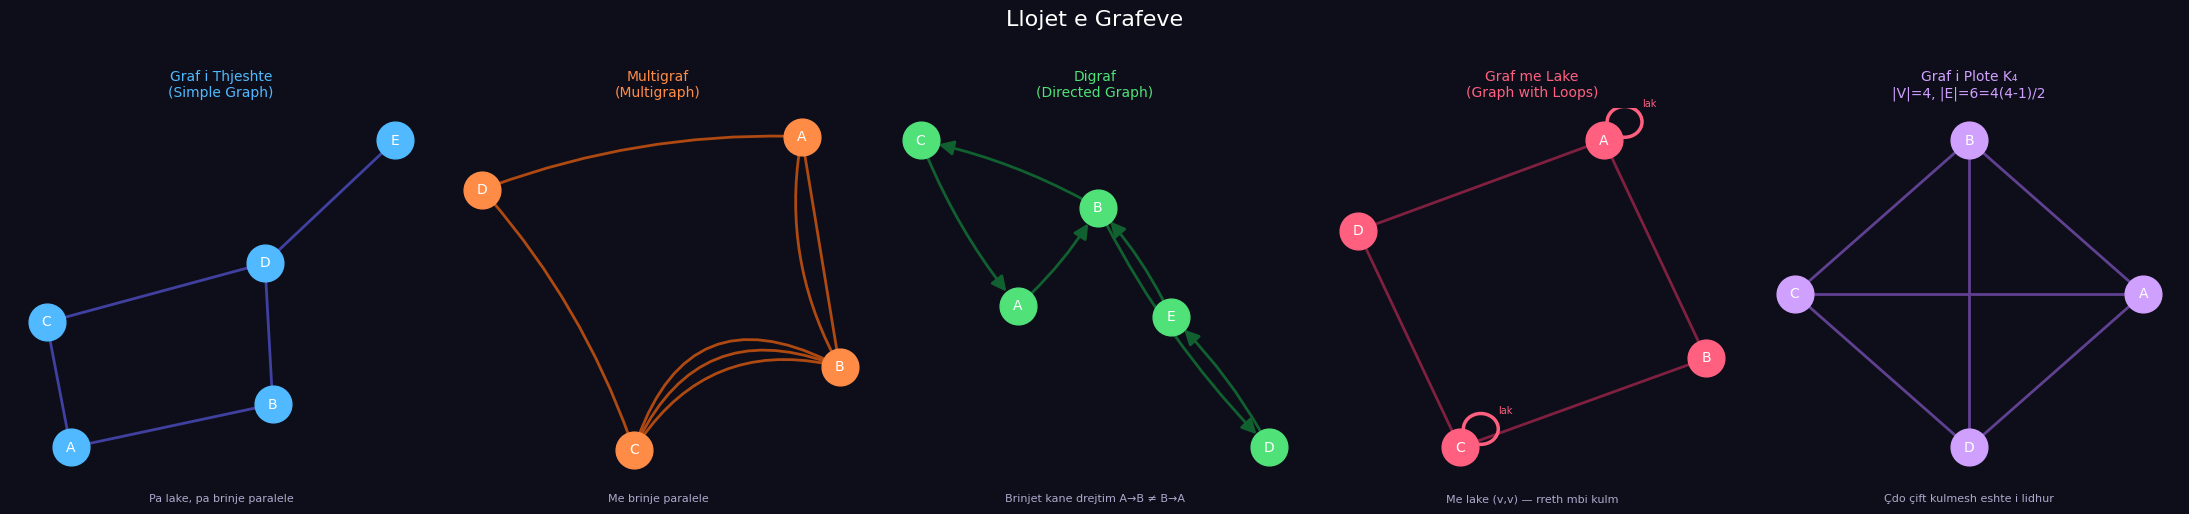

KRAHASIMI I LLOJEVE Te GRAFEVE

Graf i thjeshte:
  Rendi  |V| = 5
  Permasa |E| = 5
  A: fuqi = 2
  B: fuqi = 2
  C: fuqi = 2
  D: fuqi = 3
  E: fuqi = 1

Graf i plote K₄:
  Rendi  |V| = 4
  Permasa |E| = 6
  A: fuqi = 3
  B: fuqi = 3
  C: fuqi = 3
  D: fuqi = 3

Digraf:
  Rendi  |V| = 5
  Permasa |E| = 6
  A: fuqi-hyrese=1, fuqi-dalese=1
  B: fuqi-hyrese=2, fuqi-dalese=2
  C: fuqi-hyrese=1, fuqi-dalese=1
  D: fuqi-hyrese=1, fuqi-dalese=1
  E: fuqi-hyrese=1, fuqi-dalese=1


In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.patch.set_facecolor("#0e0e1a")
fig.suptitle("Llojet e Grafeve", color="white", fontsize=16, y=1.02)

BG   = "#0e0e1a"
seed = 42

# Graf i Thjeshte
G1 = nx.Graph()
G1.add_nodes_from(["A","B","C","D","E"])
G1.add_edges_from([("A","B"),("A","C"),("B","D"),("C","D"),("D","E")])
ax = axes[0]; ax.set_facecolor(BG)
ax.set_title("Graf i Thjeshte\n(Simple Graph)", color="#50B9FF", fontsize=10, pad=8)
pos1 = nx.spring_layout(G1, seed=seed)
nx.draw_networkx(G1, pos1, ax=ax,
    node_color="#50B9FF", node_size=700, font_color="white", font_size=10,
    edge_color="#4040a0", width=2)
ax.text(0.5,-0.06,"Pa lake, pa brinje paralele", transform=ax.transAxes,
        ha="center", color="#aaaacc", fontsize=8)
ax.axis("off")

# Multigraf
G2 = nx.MultiGraph()
G2.add_nodes_from(["A","B","C","D"])
G2.add_edges_from([
    ("A","B"),("A","B"),            # dy brinje paralele A-B
    ("B","C"),("B","C"),("B","C"),  # tri brinje paralele B-C
    ("C","D"),("D","A")
])
ax = axes[1]; ax.set_facecolor(BG)
ax.set_title("Multigraf\n(Multigraph)", color="#FF8C46", fontsize=10, pad=8)
pos2 = nx.spring_layout(G2, seed=seed)
nx.draw_networkx_nodes(G2, pos2, ax=ax, node_color="#FF8C46", node_size=700)
nx.draw_networkx_labels(G2, pos2, ax=ax, font_color="white", font_size=10)
# Vizato brinjet me rad te ndryshem per paralelet
for i,(u,v,_) in enumerate(G2.edges(keys=True)):
    rad = 0.0 + i*0.18 if (u=="A" and v=="B") or (u=="B" and v=="A") else \
          0.0 + i*0.12 if (u=="B" and v=="C") or (u=="C" and v=="B") else 0.1
    nx.draw_networkx_edges(G2, pos2, ax=ax, edgelist=[(u,v)],
        edge_color="#c05010", width=2, alpha=0.9,
        connectionstyle=f"arc3,rad={rad:.2f}")
ax.text(0.5,-0.06,"Me brinje paralele", transform=ax.transAxes,
        ha="center", color="#aaaacc", fontsize=8)
ax.axis("off")

# Digraf
G3 = nx.DiGraph()
G3.add_nodes_from(["A","B","C","D","E"])
G3.add_edges_from([
    ("A","B"),("B","C"),("C","A"),   # cikel
    ("B","D"),("D","E"),("E","B")    # cikel tjeter
])
ax = axes[2]; ax.set_facecolor(BG)
ax.set_title("Digraf\n(Directed Graph)", color="#50E178", fontsize=10, pad=8)
pos3 = nx.spring_layout(G3, seed=seed)
nx.draw_networkx(G3, pos3, ax=ax,
    node_color="#50E178", node_size=700, font_color="white", font_size=10,
    edge_color="#106030", width=2,
    arrows=True, arrowsize=22, arrowstyle="-|>",
    connectionstyle="arc3,rad=0.08")
ax.text(0.5,-0.06,"Brinjet kane drejtim A→B ≠ B→A", transform=ax.transAxes,
        ha="center", color="#aaaacc", fontsize=8)
ax.axis("off")

# Graf me Lake
G4 = nx.Graph()
G4.add_nodes_from(["A","B","C","D"])
G4.add_edges_from([("A","B"),("B","C"),("C","D"),("D","A")])
# Lake: (v,v) — nx nuk i mbeshtet direkt, i vizatojme manualisht
loops = ["A","C"]
ax = axes[3]; ax.set_facecolor(BG)
ax.set_title("Graf me Lake\n(Graph with Loops)", color="#FF6080", fontsize=10, pad=8)
pos4 = nx.spring_layout(G4, seed=seed)
nx.draw_networkx(G4, pos4, ax=ax,
    node_color="#FF6080", node_size=700, font_color="white", font_size=10,
    edge_color="#802040", width=2)
# Vizato laket si harqe
for lv in loops:
    px2, py2 = pos4[lv]
    # shnderro ne koordinata ekrani
    x_s = ax.transData.transform([px2, py2])
    circle = plt.Circle((px2+0.12, py2+0.12), 0.10,
                         fill=False, color="#FF6080", linewidth=2.5,
                         transform=ax.transData)
    ax.add_patch(circle)
    ax.text(px2+0.22, py2+0.22, "lak", color="#FF6080", fontsize=7,
            transform=ax.transData)
ax.text(0.5,-0.06,"Me lake (v,v) — rreth mbi kulm", transform=ax.transAxes,
        ha="center", color="#aaaacc", fontsize=8)
ax.axis("off")

# Graf i Plote K₄
G5 = nx.complete_graph(4)
mapping = {0:"A", 1:"B", 2:"C", 3:"D"}
G5 = nx.relabel_nodes(G5, mapping)
ax = axes[4]; ax.set_facecolor(BG)
n_nodes = G5.number_of_nodes()
n_edges = G5.number_of_edges()
ax.set_title(f"Graf i Plote K₄\n|V|={n_nodes}, |E|={n_edges}={n_nodes}({n_nodes}-1)/2",
             color="#D0A0FF", fontsize=10, pad=8)
pos5 = nx.circular_layout(G5)
nx.draw_networkx(G5, pos5, ax=ax,
    node_color="#D0A0FF", node_size=700, font_color="white", font_size=10,
    edge_color="#604090", width=2)
ax.text(0.5,-0.06,"Çdo çift kulmesh eshte i lidhur", transform=ax.transAxes,
        ha="center", color="#aaaacc", fontsize=8)
ax.axis("off")

plt.tight_layout()
plt.show()

# Analiza e çdo tipi
print("=" * 55)
print("KRAHASIMI I LLOJEVE Te GRAFEVE")
print("=" * 55)
data = [
    ("Graf i thjeshte",  G1, False),
    ("Graf i plote K₄",  G5, False),
    ("Digraf",           G3, True),
]
for emri, G, drejtuar in data:
    print(f"\n{emri}:")
    print(f"  Rendi  |V| = {G.number_of_nodes()}")
    print(f"  Permasa |E| = {G.number_of_edges()}")
    if drejtuar:
        for n in G.nodes():
            print(f"  {n}: fuqi-hyrese={G.in_degree(n)}, fuqi-dalese={G.out_degree(n)}")
    else:
        for n in G.nodes():
            print(f"  {n}: fuqi = {G.degree(n)}")

---

## Ushtrimi 4 — Paraqitja e Grafeve: Liste dhe Matrice Fqinjesie

### Dy menyrat kryesore te paraqitjes

Nje graf mund te paraqitet ne dy menyra ekuivalente:

#### 1. Lista e Fqinjesise *(Adjacency List)*
Per çdo kulm **v ∈ V**, ruajme listen e kulmeve me te cilat lidhet:
```
A → [B, C]
B → [A, D]
C → [A, D]
D → [B, C]
```
**Hapesire:** O(|V| + |E|) — efikase per grafe te rralla *(sparse graphs)*

#### 2. Matrica e Fqinjesise *(Adjacency Matrix)*
Matrice **|V| × |V|** ku elementi **A[i][j] = 1** nese ekziston brinja (i,j), **0** ndryshe:
```
   A  B  C  D
A  0  1  1  0
B  1  0  0  1
C  1  0  0  1
D  0  1  1  0
```
**Hapesire:** O(|V|²) — efikase per grafe te dendura *(dense graphs)*

### Verejtje per digrafet
Tek digrafet, **A[i][j] ≠ A[j][i]** — matrica nuk eshte simetrike.

### Pyetje
- Si duket matrica e fqinjesise per grafin e plote **K₄**?
- Si ndryshon lista e fqinjesise midis grafit te padrejtuar dhe digrafit?
- Cila paraqitje eshte me efikase kur |E| ≈ |V|²? Po kur |E| ≈ |V|?

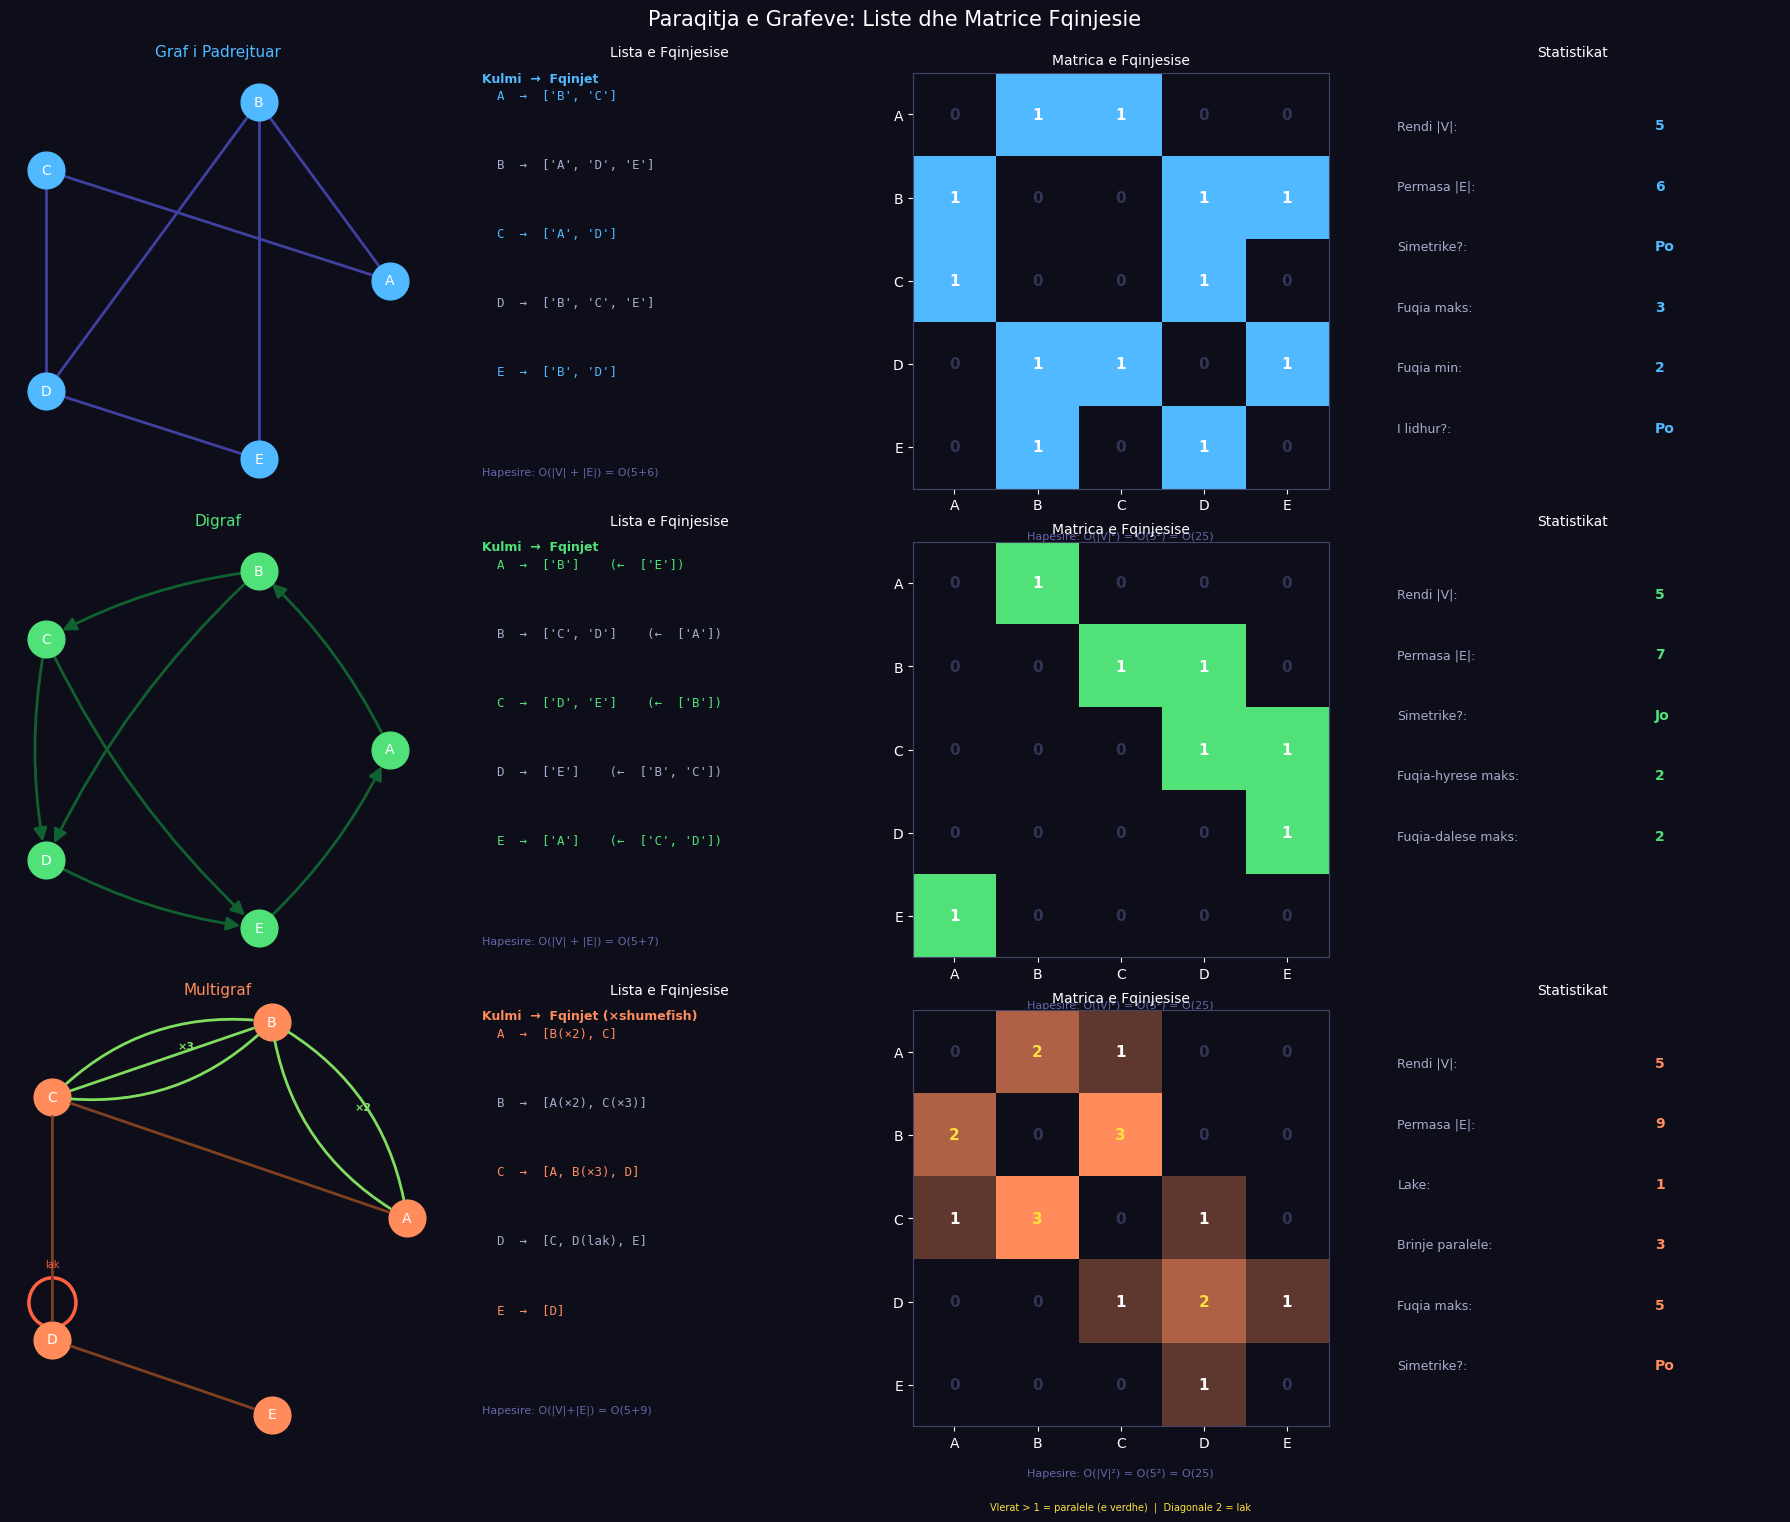

PARAQITJA TEKSTUALE E GRAFEVE

Graf i Padrejtuar:
  V = ['A', 'B', 'C', 'D', 'E']
  E = [('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'D'), ('D', 'E')]
  Lista e fqinjesise:
    A: ['B', 'C']
    B: ['A', 'D', 'E']
    C: ['A', 'D']
    D: ['B', 'C', 'E']
    E: ['B', 'D']

Digraf:
  V = ['A', 'B', 'C', 'D', 'E']
  E = [('A', 'B'), ('B', 'C'), ('B', 'D'), ('C', 'D'), ('C', 'E'), ('D', 'E'), ('E', 'A')]
  Lista e fqinjesise:
    A: ['B']
    B: ['C', 'D']
    C: ['D', 'E']
    D: ['E']
    E: ['A']

Multigraf:
  V = ['A', 'B', 'C', 'D', 'E']
  E = [('A', 'B'), ('A', 'B'), ('A', 'C'), ('B', 'C'), ('B', 'C'), ('B', 'C'), ('C', 'D'), ('D', 'E'), ('D', 'D')]  (me dublikate)
  Lake: 1
  Lista e fqinjesise (me multiplicitet):
    A: [B(×2), C]
    B: [A(×2), C(×3)]
    C: [A, B(×3), D]
    D: [C, D(lak), E]
    E: [D]

Matrica (vlerat > 1 tregojne brinje paralele):
       A   B   C   D   E
  A    0   2   1   0   0
  B    2   0   3   0   0
  C    1   3   0   1   0
  D    0   0   1   2

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import Counter

# Tri grafe per krahasim
# ----------------------------------
# Graf i padrejtuar
G_und = nx.Graph()
G_und.add_nodes_from(["A","B","C","D","E"])
G_und.add_edges_from([("A","B"),("A","C"),("B","D"),("C","D"),("D","E"),("B","E")])

# Digraf
G_dir = nx.DiGraph()
G_dir.add_nodes_from(["A","B","C","D","E"])
G_dir.add_edges_from([
    ("A","B"),("B","C"),("C","D"),("D","E"),("E","A"),
    ("B","D"),("C","E")
])

# Multigraf
G_mul = nx.MultiGraph()
G_mul.add_nodes_from(["A","B","C","D","E"])
G_mul.add_edges_from([
    ("A","B"), ("A","B"),           # 2 brinje paralele A-B
    ("A","C"),
    ("B","C"), ("B","C"), ("B","C"),# 3 brinje paralele B-C
    ("C","D"),
    ("D","E"),
    ("D","D"),                       # lak ne D
])

fig = plt.figure(figsize=(18, 15))
fig.patch.set_facecolor("#0e0e1a")
fig.suptitle("Paraqitja e Grafeve: Liste dhe Matrice Fqinjesie", 
             color="white", fontsize=15, y=0.99)

BG = "#0e0e1a"
grafe = [
    (G_und, "Graf i Padrejtuar", "#50B9FF", "#4040a0", False),
    (G_dir, "Digraf",            "#50E178", "#106030", True),
]

for gi, (G, title, ncol, ecol, directed) in enumerate(grafe):
    nodes_sorted = sorted(G.nodes())
    n = len(nodes_sorted)
    idx = {v: i for i, v in enumerate(nodes_sorted)}

    # Vizatimi i grafit
    ax_g = fig.add_subplot(3, 4, gi*4 + 1)
    ax_g.set_facecolor(BG)
    ax_g.set_title(title, color=ncol, fontsize=11, pad=6)
    pos = nx.circular_layout(G)
    kw = dict(node_color=ncol, node_size=700, font_color="white",
              font_size=10, edge_color=ecol, width=2)
    if directed:
        kw.update(arrows=True, arrowsize=20, connectionstyle="arc3,rad=0.1")
    nx.draw_networkx(G, pos, ax=ax_g, **kw)
    ax_g.axis("off")

    # Lista e fqinjesise
    ax_l = fig.add_subplot(3, 4, gi*4 + 2)
    ax_l.set_facecolor(BG)
    ax_l.set_title("Lista e Fqinjesise", color="white", fontsize=10, pad=6)
    ax_l.axis("off")
    y_start = 0.92
    ax_l.text(0.05, y_start + 0.04, "Kulmi  →  Fqinjet", 
              transform=ax_l.transAxes, color=ncol, fontsize=9, fontweight="bold")
    for vi, v in enumerate(nodes_sorted):
        if directed:
            nbrs = sorted(G.successors(v))
            in_nbrs = sorted(G.predecessors(v))
            line = f"  {v}  →  {nbrs}    (←  {in_nbrs})"
        else:
            nbrs = sorted(G.neighbors(v))
            line = f"  {v}  →  {nbrs}"
        color = ncol if vi % 2 == 0 else "#aaaacc"
        ax_l.text(0.05, y_start - vi*0.16, line,
                  transform=ax_l.transAxes, color=color, fontsize=9,
                  fontfamily="monospace")
    # Hapesira
    sp = "|V| + |E|" if not directed else "|V| + |E|"
    ax_l.text(0.05, 0.05, f"Hapesire: O({sp}) = O({n}+{G.number_of_edges()})",
              transform=ax_l.transAxes, color="#6666aa", fontsize=8)

    # Matrica e fqinjesise
    ax_m = fig.add_subplot(3, 4, gi*4 + 3)
    ax_m.set_facecolor(BG)
    ax_m.set_title("Matrica e Fqinjesise", color="white", fontsize=10, pad=6)

    mat = np.zeros((n, n), dtype=int)
    for u, v in G.edges():
        mat[idx[u]][idx[v]] = 1
        if not directed:
            mat[idx[v]][idx[u]] = 1

    cmap = mcolors.LinearSegmentedColormap.from_list("grf", ["#0e0e1a", ncol])
    im = ax_m.imshow(mat, cmap=cmap, vmin=0, vmax=1, aspect="equal")
    ax_m.set_xticks(range(n)); ax_m.set_yticks(range(n))
    ax_m.set_xticklabels(nodes_sorted, color="white", fontsize=10)
    ax_m.set_yticklabels(nodes_sorted, color="white", fontsize=10)
    ax_m.tick_params(colors="white")
    for spine in ax_m.spines.values(): spine.set_edgecolor("#444466")
    # Vlerat brenda matrices
    for i in range(n):
        for j in range(n):
            val = mat[i][j]
            col_txt = "white" if val == 1 else "#333355"
            ax_m.text(j, i, str(val), ha="center", va="center",
                      color=col_txt, fontsize=11, fontweight="bold")
    ax_m.text(0.5, -0.12, f"Hapesire: O(|V|²) = O({n}²) = O({n*n})",
              transform=ax_m.transAxes, ha="center", color="#6666aa", fontsize=8)

    # Statistikat
    ax_s = fig.add_subplot(3, 4, gi*4 + 4)
    ax_s.set_facecolor(BG)
    ax_s.set_title("Statistikat", color="white", fontsize=10, pad=6)
    ax_s.axis("off")
    stats = [
        ("Rendi |V|",    str(G.number_of_nodes())),
        ("Permasa |E|",  str(G.number_of_edges())),
        ("Simetrike?",   "Po" if not directed else "Jo"),
    ]
    if directed:
        stats += [
            ("Fuqia-hyrese maks",  str(max(d for _,d in G.in_degree()))),
            ("Fuqia-dalese maks",  str(max(d for _,d in G.out_degree()))),
        ]
    else:
        stats += [
            ("Fuqia maks", str(max(d for _,d in G.degree()))),
            ("Fuqia min",  str(min(d for _,d in G.degree()))),
            ("I lidhur?",  "Po" if nx.is_connected(G) else "Jo"),
        ]
    for k, (lbl, val) in enumerate(stats):
        ax_s.text(0.08, 0.85 - k*0.14, f"{lbl}:", 
                  transform=ax_s.transAxes, color="#aaaacc", fontsize=9)
        ax_s.text(0.70, 0.85 - k*0.14, val,
                  transform=ax_s.transAxes, color=ncol, fontsize=10, fontweight="bold")

G = G_mul
mcol = "#FF8C5A"   # portokalli
mecol = "#804020"   # ngjyre e erret per brinje
nodes_sorted = sorted(G.nodes())
n = len(nodes_sorted)
idx = {v: i for i, v in enumerate(nodes_sorted)}
pos = nx.circular_layout(G)

# Vizatimi i multigrafit
ax_g = fig.add_subplot(3, 4, 9)
ax_g.set_facecolor(BG)
ax_g.set_title("Multigraf", color=mcol, fontsize=11, pad=6)

# Vizatojme kulmet dhe pershkrimet
nx.draw_networkx_nodes(G, pos, ax=ax_g, node_color=mcol, node_size=700)
nx.draw_networkx_labels(G, pos, ax=ax_g, font_color="white", font_size=10)

# Numerojme brinjet per çdo çift (perfshire lake)
edge_groups = {}
for u, v in G.edges():
    key = (min(u,v), max(u,v))
    edge_groups[key] = edge_groups.get(key, 0) + 1

# Vizatojme brinjet me drejtime te ndryshme per paralelet
for (u, v), count in edge_groups.items():
    if u == v:
        # Lak: vizatojme rreth
        x, y = pos[u]
        loop = plt.Circle((x, y + 0.18), 0.12, fill=False,
                          color="#FF6040", lw=2.5, linestyle="-")
        ax_g.add_patch(loop)
        ax_g.text(x, y + 0.35, "lak", ha="center", color="#FF6040", fontsize=7)
    else:
        for i in range(count):
            if count == 1:
                rad = 0.0
            else:
                rad = -0.25 + 0.5 * i / (count - 1)
            # Ngjyre me e celur per brinje paralele
            col = "#80DD60" if count > 1 else mecol
            ax_g.annotate("", xy=pos[v], xytext=pos[u],
                arrowprops=dict(arrowstyle="-", color=col, lw=2,
                                connectionstyle=f"arc3,rad={rad}",
                                shrinkA=14, shrinkB=14))
        if count > 1:
            mx_ = (pos[u][0] + pos[v][0]) / 2
            my_ = (pos[u][1] + pos[v][1]) / 2
            ax_g.text(mx_ + 0.08, my_ + 0.05, f"×{count}",
                      color="#80DD60", fontsize=8, fontweight="bold")
ax_g.axis("off")

# Lista e fqinjesise
ax_l = fig.add_subplot(3, 4, 10)
ax_l.set_facecolor(BG)
ax_l.set_title("Lista e Fqinjesise", color="white", fontsize=10, pad=6)
ax_l.axis("off")
y_start = 0.92
ax_l.text(0.05, y_start + 0.04, "Kulmi  →  Fqinjet (×shumefish)",
          transform=ax_l.transAxes, color=mcol, fontsize=9, fontweight="bold")

for vi, v in enumerate(nodes_sorted):
    # Numero fqinjet me multiplicitet
    nbr_counts = Counter()
    for u, w, _ in G.edges(v, keys=True):
        nbr_counts[w] += 1
    # Formato: B(×2), C
    parts = []
    for nbr in sorted(nbr_counts.keys()):
        cnt = nbr_counts[nbr]
        if nbr == v:
            parts.append(f"{nbr}(lak)")
        elif cnt > 1:
            parts.append(f"{nbr}(×{cnt})")
        else:
            parts.append(nbr)
    line = f"  {v}  →  [{', '.join(parts)}]"
    color = mcol if vi % 2 == 0 else "#aaaacc"
    ax_l.text(0.05, y_start - vi * 0.16, line,
              transform=ax_l.transAxes, color=color, fontsize=9,
              fontfamily="monospace")

n_edges_mul = G.number_of_edges()
ax_l.text(0.05, 0.05, f"Hapesire: O(|V|+|E|) = O({n}+{n_edges_mul})",
          transform=ax_l.transAxes, color="#6666aa", fontsize=8)

# Matrica e fqinjesise (vlera = numri i brinjeve)
ax_m = fig.add_subplot(3, 4, 11)
ax_m.set_facecolor(BG)
ax_m.set_title("Matrica e Fqinjesise", color="white", fontsize=10, pad=6)

mat = np.zeros((n, n), dtype=int)
# Perdorim edge_groups per matricen
for (u, v), count in edge_groups.items():
    if u == v:
        mat[idx[u]][idx[v]] = 2 * count   # laku = 2 per brinje
    else:
        mat[idx[u]][idx[v]] = count
        mat[idx[v]][idx[u]] = count

max_val = max(mat.max(), 1)
cmap = mcolors.LinearSegmentedColormap.from_list("grf", ["#0e0e1a", mcol])
ax_m.imshow(mat, cmap=cmap, vmin=0, vmax=max_val, aspect="equal")
ax_m.set_xticks(range(n)); ax_m.set_yticks(range(n))
ax_m.set_xticklabels(nodes_sorted, color="white", fontsize=10)
ax_m.set_yticklabels(nodes_sorted, color="white", fontsize=10)
ax_m.tick_params(colors="white")
for spine in ax_m.spines.values(): spine.set_edgecolor("#444466")

for i in range(n):
    for j in range(n):
        val = mat[i][j]
        if val >= 2:
            col_txt = "#FFE040"   # e verdhe per vlera > 1 (paralele)
        elif val == 1:
            col_txt = "white"
        else:
            col_txt = "#333355"
        ax_m.text(j, i, str(val), ha="center", va="center",
                  color=col_txt, fontsize=11, fontweight="bold")

ax_m.text(0.5, -0.12, f"Hapesire: O(|V|²) = O({n}²) = O({n*n})",
          transform=ax_m.transAxes, ha="center", color="#6666aa", fontsize=8)
ax_m.text(0.5, -0.20, "Vlerat > 1 = paralele (e verdhe)  |  Diagonale 2 = lak",
          transform=ax_m.transAxes, ha="center", color="#FFE040", fontsize=7)

# Statistikat e multigrafit
ax_s = fig.add_subplot(3, 4, 12)
ax_s.set_facecolor(BG)
ax_s.set_title("Statistikat", color="white", fontsize=10, pad=6)
ax_s.axis("off")

n_loops = sum(1 for u, v in G.edges() if u == v)
n_parallel = sum(c - 1 for (u, v), c in edge_groups.items() if c > 1 and u != v)

stats_mul = [
    ("Rendi |V|",       str(n)),
    ("Permasa |E|",     str(n_edges_mul)),
    ("Lake",            str(n_loops)),
    ("Brinje paralele", str(n_parallel)),
    ("Fuqia maks",      str(max(d for _, d in G.degree()))),
    ("Simetrike?",      "Po"),
]
for k, (lbl, val) in enumerate(stats_mul):
    ax_s.text(0.08, 0.85 - k * 0.14, f"{lbl}:",
              transform=ax_s.transAxes, color="#aaaacc", fontsize=9)
    ax_s.text(0.70, 0.85 - k * 0.14, val,
              transform=ax_s.transAxes, color=mcol, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


# Output tekst

print("=" * 55)
print("PARAQITJA TEKSTUALE E GRAFEVE")
print("=" * 55)
for G, title, *_ in grafe:
    print(f"\n{title}:")
    print(f"  V = {sorted(G.nodes())}")
    print(f"  E = {sorted(G.edges())}")
    print("  Lista e fqinjesise:")
    for v in sorted(G.nodes()):
        print(f"    {v}: {sorted(G.neighbors(v) if hasattr(G,'neighbors') else G.successors(v))}")

# Multigraf tekst
print(f"\nMultigraf:")
print(f"  V = {sorted(G_mul.nodes())}")
print(f"  E = {list(G_mul.edges())}  (me dublikate)")
print(f"  Lake: {n_loops}")
print("  Lista e fqinjesise (me multiplicitet):")
for v in sorted(G_mul.nodes()):
    nbr_counts = Counter()
    for u, w, _ in G_mul.edges(v, keys=True):
        nbr_counts[w] += 1
    parts = []
    for nbr in sorted(nbr_counts.keys()):
        cnt = nbr_counts[nbr]
        if nbr == v:
            parts.append(f"{nbr}(lak)")
        elif cnt > 1:
            parts.append(f"{nbr}(×{cnt})")
        else:
            parts.append(nbr)
    print(f"    {v}: [{', '.join(parts)}]")
print(f"\nMatrica (vlerat > 1 tregojne brinje paralele):")
print(f"     {' '.join(f'{v:>3}' for v in nodes_sorted)}")
for i, vi in enumerate(nodes_sorted):
    print(f"  {vi}  {' '.join(f'{mat[i][j]:>3}' for j in range(n))}")